In [1]:
import hist as h
import dask_awkward as dak
import numpy as np
import hist_functions
from hist_functions import make_hist, make_diff_hist, make_overlay_hist, os_ss_hist
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
vector.register_awkward()

NanoAODSchema.warn_missing_crossrefs = False

In [2]:
events = NanoEventsFactory.from_root(
    {"../../datasets/WJets_ToLNu_NANOAODSIM.root": "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset":"WJets"},
    mode="dask"
).events()
events

dask.awkward<from-uproot, npartitions=1>

In [3]:
n_events = dak.num(events, axis=0)
print("Total number of events in the dataset:", n_events.compute())

nMuons = dak.num(events.Muon.pt, axis=0)

Total number of events in the dataset: 2006990


In [109]:
test_mu = events.Muon
nMu = dak.num(test_mu.pt)
nMu = dak.sum(nMu)
print("Total number of muons in the dataset:", nMu.compute())

cMuPassCuts = (
    (test_mu.pt < 25) &
    (abs(test_mu.eta) < 2.4) & 
    (test_mu.pfRelIso04_all > 0.2) &  
    (test_mu.tightId == 1)
 )
soft_muon = test_mu[cMuPassCuts]

# Impact parameter significance cut (2D)
ipSigCut_nom = 2.0
ipSigCut_syst = 1.0  # optional systematic variation

dxy_err_ok = (soft_muon.dxyErr > 0)
sip2d = abs(soft_muon.dxy) / soft_muon.dxyErr
# ipSigMask = dxy_err_ok & (sip2d > ipSigCut_nom)
ipSigMask = dxy_err_ok & (sip2d > ipSigCut_syst)  # systematic alternative

soft_muon = soft_muon[ipSigMask]



nsoft_muons = dak.num(soft_muon.pt)
nsoft_muons_total = dak.sum(nsoft_muons)
print("Total number of soft muons passing the cut:", nsoft_muons_total.compute())

Total number of muons in the dataset: 690350
Total number of soft muons passing the cut: 12832


In [90]:
test_mu = events.Muon
test_MET = events.MET
nMu = dak.num(test_mu.pt)
nMu = dak.sum(nMu)
print("Total number of muons in the dataset:", nMu.compute())

# Test cuts to see which ones reduce the most number of muons:
test_cuts = (
    (test_mu.pt > 25) &
    (abs(test_mu.eta) < 2.4) &
    (test_mu.tightId == 1) &
    (abs(test_mu.pfRelIso04_all) < 0.15)
)

Mt = np.sqrt(2 * test_mu.pt * test_MET.pt * (1 - np.cos(test_mu.phi - test_MET.phi)))
Mt_Cut = (Mt > 50)
test_cuts = test_cuts & Mt_Cut
test_mu = test_mu[test_cuts]

# Select events with exactly one W muon:
nMu = dak.num(test_mu.pt)
evt_has_1WMu = (nMu == 1)
test_mu = test_mu[evt_has_1WMu] 

nMu = dak.num(test_mu.pt)
nMu = dak.sum(nMu)
print("Total number of muons after cut:", nMu.compute())

Total number of muons in the dataset: 690350
Total number of muons after cut: 233754


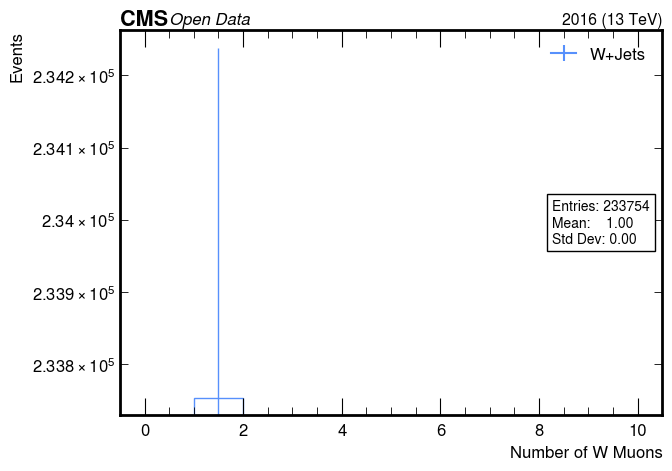

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Number of W Muons', ylabel='Events'>,
 Hist(Regular(10, 0, 10, label='Axis 0'), storage=Double()) # Sum: 233754.0)

In [91]:
nMu = dak.num(test_mu.pt)

make_hist(
    nMu,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of W Muons",
    ylabel="Events",
    label="W+Jets",
    logy=True,
    histtype='step',
    show_stats=True,
    ax=None,
    fname=None,
    show=True,
    return_hist=True
)

In [ ]:
# Collections of physics objects that we want for this analysis:
Muon = events.Muon
MET = events.MET
Jet = events.Jet

nMuons = dak.num(Muon.pt)
total_Muons = dak.sum(nMuons)
print("Total number of muons in the dataset:", total_Muons.compute())

# W -> Mu Nu Channel Selection:
W_MuMask = (
    (Muon.pt > 25) &
    (abs(Muon.eta) < 2.4) &
    (Muon.tightId == 1) &
    (Muon.pfRelIso04_all < 0.15)
    )
Mt = np.sqrt(2 * Muon.pt * MET.pt * (1 - np.cos(Muon.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Muon[W_MuMask]
# Select events with exactly one W muon:
nMu = dak.num(W_Muons.pt)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

nMu = dak.num(W_Muons.pt)
nMu = dak.sum(nMu)
print("Total number of W muons:", nMu.compute())

###############################################
## C-jet -> Mu X Channel Selection (soft muon)
###############################################

cMuPassCuts = (
    (Muon.pt < 25) &
    (abs(Muon.eta) < 2.4) &
    (Muon.pfRelIso04_all > 0.2) & 
    (Muon.tightId == 1)
 )
soft_muon = Muon[cMuPassCuts]

# Print the number of soft muons passing the selection:
nSoftMuons = dak.num(soft_muon.pt)
total_SoftMuons = dak.sum(nSoftMuons)
print("Total number of soft muons before IP Cut:", total_SoftMuons.compute())

# Impact parameter significance cut (2D)
# Nominal cut: > 2 ; systematic variation: > 1
ipSigCut_nom = 2.0
ipSigCut_syst = 1.0  # optional systematic variation

dxy_err_ok = abs(soft_muon.dxyErr) > 0 # just a safe check to avoid division by zero
sip2d = abs(soft_muon.dxy) / soft_muon.dxyErr 

# choose ONE of these masks depending on what you want to run
# ipSigMask = dxy_err_ok & (sip2d > ipSigCut_nom)
ipSigMask = dxy_err_ok & (sip2d > ipSigCut_syst)  # systematic alternative

soft_muon = soft_muon[ipSigMask]

# Print the number of soft muons passing the selection:
nSoftMuons = dak.num(soft_muon.pt)
total_SoftMuons = dak.sum(nSoftMuons)
print("Total number of soft muons after IP Cut:", total_SoftMuons.compute())

###############################################
## dR matching (soft muon <-> jets)
## - builds all muon-jet pairs per event
## - picks nearest jet per muon
## - requires min dR < dr_cut
###############################################

dr_cut = 0.4

# Jets eligible for matching (apply your jet kinematic cuts here)
jets = Jet[
    (Jet.pt > 30) &
    (abs(Jet.eta) < 2.4)
]

# Summary of jet availability for matching:
njets = dak.num(jets.pt)
total_Jets = dak.sum(njets)
print("Total number of jets eligible for matching:", total_Jets.compute())

# Pairwise muon-jet combinations within each event: (evt, nMu, nJet)
pairs = dak.cartesian({"mu": soft_muon, "jet": jets}, nested=True)

# Calculate deltaR for each muon-jet pair 
dr_pairs = pairs["mu"].delta_r(pairs["jet"])

# Nearest jet per muon (handles events with 0 jets by returning None)
# axis=0 (nEvent), axis=1 (nMu), axis=2 (nJet)
min_dr = dak.min(dr_pairs, axis=2) # Gets the nearest jet distance for each muon
best_jet_idx = dak.argmin(dr_pairs, axis=2) # Gets the index of the nearest jet for each muon 
min_dr_filled = dak.fill_none(min_dr, np.inf) # fills events with no jets (min_dr=None) with inf so they fail the dr_cut

# Require a valid match within dr_cut
has_match = (min_dr_filled < dr_cut)

# Keep only matched soft muons and their matched jets
soft_muon_in_goodjet = soft_muon[has_match]
c_Jets = jets[best_jet_idx]
c_Jets = c_Jets[has_match]

# Select events with atleast one c-jet:
nC_Jets = dak.num(c_Jets.pt)
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

# Total number of cJets in the dataset:
nC_Jets = dak.num(c_Jets.pt)
total_cJets = dak.sum(nC_Jets)
print("Total number of c-jets in the dataset:", total_cJets.compute())

Total number of muons in the dataset: 690350
Total number of W muons: 233754
Total number of soft muons before IP Cut: 40188
Total number of soft muons after IP Cut: 12832
Total number of jets eligible for matching: 1121585
Total number of c-jets in the dataset: 3197
Total number of c-jets in the dataset: 3197


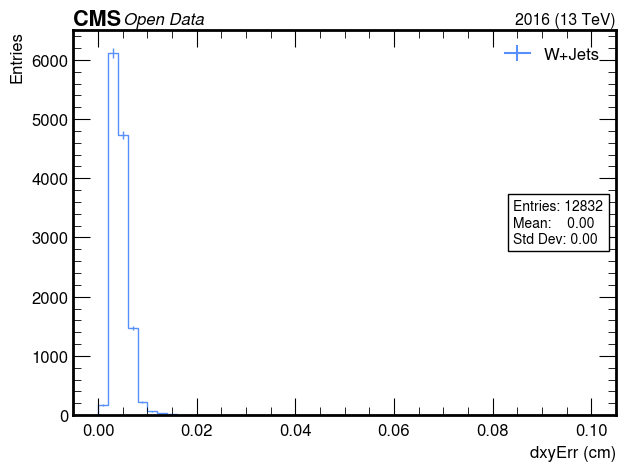

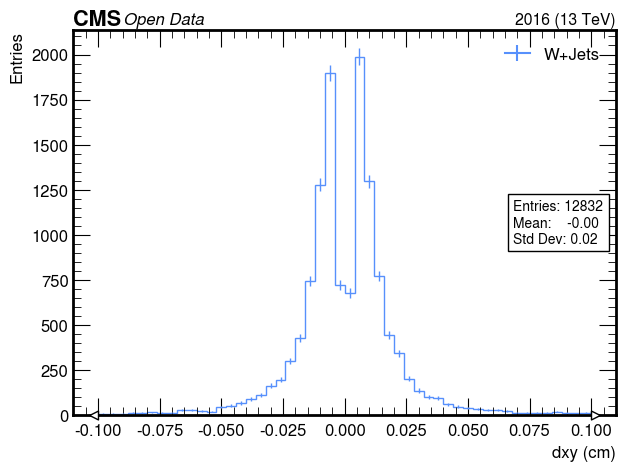

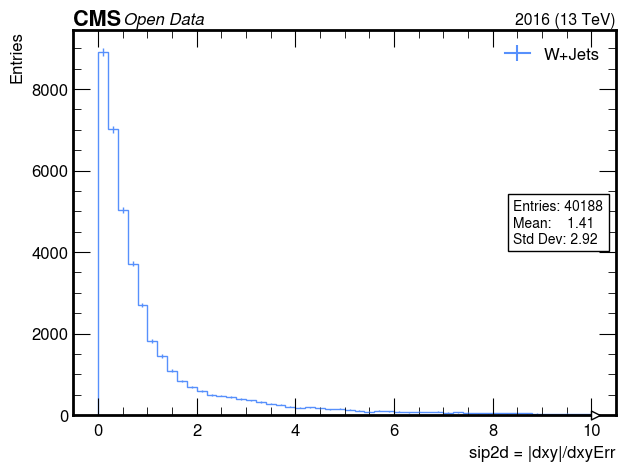

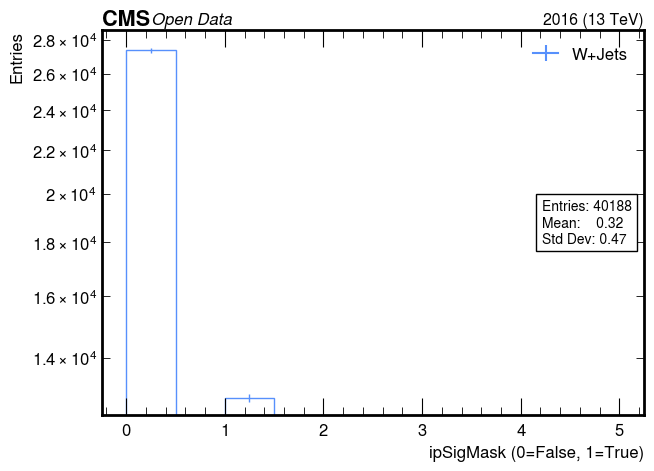

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='ipSigMask (0=False, 1=True)', ylabel='Entries'>,
 Hist(Regular(10, 0, 5, label='Axis 0'), storage=Double()) # Sum: 40188.0)

In [97]:
# Distributions: sip2d and ipSigMask (as 0/1)
soft_muon_sigma = dak.flatten(soft_muon.dxyErr)
soft_muon_dxy = dak.flatten(soft_muon.dxy)
sip2d_flat = dak.flatten(sip2d)
ipSigMask_int = dak.flatten(ipSigMask)

make_hist(
    soft_muon_sigma,
    nBins=50,
    lo=0,
    hi=0.1,
    xlabel="dxyErr (cm)",
    ylabel="Entries",
    label="W+Jets",
    logy=False,
    histtype='step',
    show_stats=True,
    ax=None,
    fname=None,
    show=True,
    return_hist=True
)

make_hist(
    soft_muon_dxy,
    nBins=50,
    lo=-0.1,
    hi=0.1,
    xlabel="dxy (cm)",
    ylabel="Entries",
    label="W+Jets",
    logy=False,
    histtype='step',
    show_stats=True,
    ax=None,
    fname=None,
    show=True,
    return_hist=True
)

make_hist(
    sip2d_flat,
    nBins=50,
    lo=0,
    hi=10,
    xlabel="sip2d = |dxy|/dxyErr",
    ylabel="Entries",
    label="W+Jets",
    logy=False,
    histtype='step',
    show_stats=True,
    ax=None,
    fname=None,
    show=True,
    return_hist=True
)

make_hist(
    ipSigMask_int,
    nBins=10,
    lo=0,
    hi=5,
    xlabel="ipSigMask (0=False, 1=True)",
    ylabel="Entries",
    label="W+Jets",
    logy=True,
    histtype='step',
    show_stats=True,
    ax=None,
    fname=None,
    show=True,
    return_hist=True
)

In [104]:
W_Muons_Pt = dak.flatten(W_Muons.pt)
cJet_Pt = dak.flatten(c_Jets.pt)

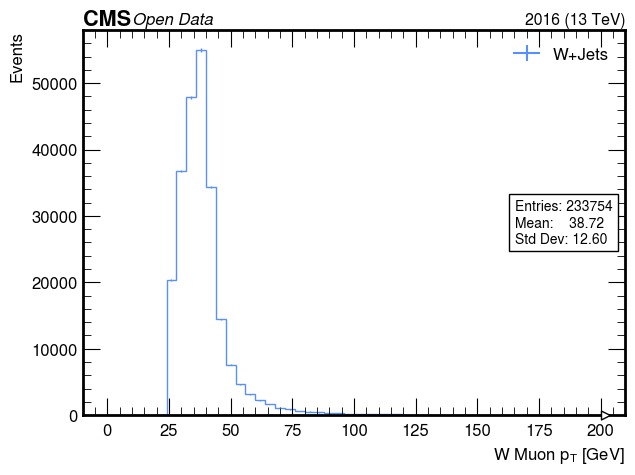

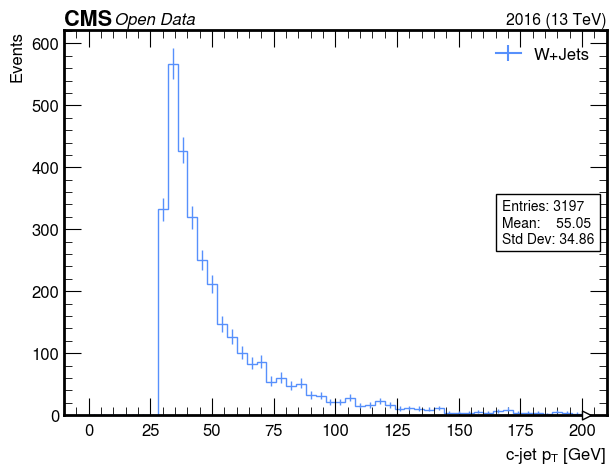

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='c-jet $p_{T}$ [GeV]', ylabel='Events'>,
 Hist(Regular(50, 0, 200, label='Axis 0'), storage=Double()) # Sum: 3168.0 (3197.0 with flow))

In [105]:
make_hist(
    W_Muons_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="W Muon $p_{T}$ [GeV]",
    ylabel="Events",
    label="W+Jets",
    logy=False,
    histtype='step',
    show_stats=True,
    ax=None,
    fname="Plots/W_Muon_Pt_selection.png",
    show=True,
    return_hist=True
)

make_hist(
    data=cJet_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="c-jet $p_{T}$ [GeV]",
    ylabel="Events",
    label="W+Jets",
    fname="Plots/c_Jet_Pt_min_deltaR_selection.png",
    logy=False,
    ax=None,
    show=True,
    return_hist=True,
    show_stats=True,
    histtype='step'
)

## Electron study:

In [59]:
# Collections of physics objects that we want for this analysis:
Electron = events.Electron
MET = events.MET
Jet = events.Jet

nElectrons = dak.num(Electron.pt)
total_Electrons = dak.sum(nElectrons)
print("Total number of electrons in the dataset:", total_Electrons.compute())

# W -> Electron Nu Channel Selection:
W_ElectronMask = (
    (Electron.pt > 30) &
    (abs(Electron.eta) < 2.4) 
    )
Mt = np.sqrt(2 * Electron.pt * MET.pt * (1 - np.cos(Electron.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_ElectronMask = W_ElectronMask & Mt_Cut
W_Electrons = Electron[W_ElectronMask]
# Select events with exactly one W electron:
nElectron = dak.num(W_Electrons.pt)
evt_has_1WElectron = (nElectron == 1)

W_Electrons = W_Electrons[evt_has_1WElectron] 

###############################################
## C-jet -> e X Channel Selection (soft electron)
###############################################

cMuPassCuts = (
    (Electron.pt < 25) &
    (abs(Electron.eta) < 2.4) 
    )
soft_electron = Electron[cMuPassCuts]

# Print the number of soft electrons passing the selection:
nSoftElectrons = dak.num(soft_electron.pt)
total_SoftElectrons = dak.sum(nSoftElectrons)
print("Total number of soft electrons in the dataset:", total_SoftElectrons.compute())

###############################################
## dR matching (soft electron <-> jets)
## - builds all electron-jet pairs per event
## - picks nearest jet per electron
## - requires min dR < dr_cut
###############################################

dr_cut = 0.4

# Jets eligible for matching (apply your jet kinematic cuts here)
jets_for_match = Jet[
    (Jet.pt > 30) &
    (abs(Jet.eta) < 2.4)
]

# Summary of jet availability for matching:
njets = dak.num(jets_for_match.pt)
total_Jets = dak.sum(njets)
print("Number of jets eligible for matching:", total_Jets.compute())

# Pairwise electron-jet combinations within each event: (evt, nElectron, nJet)
pairs = dak.cartesian({"electron": soft_electron, "jet": jets_for_match}, nested=True)

# Calculate deltaR for each electron-jet pair (phi wrapping handled internally)
dr_pairs = pairs["electron"].delta_r(pairs["jet"])

# Nearest jet per electron (handles events with 0 jets by returning None)
min_dr = dak.min(dr_pairs, axis=2)
best_jet_idx = dak.argmin(dr_pairs, axis=2)
min_dr_filled = dak.fill_none(min_dr, np.inf)
# Require a valid match within dr_cut
has_match = (min_dr_filled < dr_cut)

# Keep only matched soft electrons and their matched jets
soft_electron_in_goodjet = soft_electron[has_match]
c_Jets = jets_for_match[best_jet_idx]
c_Jets = c_Jets[has_match]

nC_Jets = dak.num(c_Jets.pt)
# Select events with atleast one c-jet:
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

Total number of electrons in the dataset: 682951
Total number of soft electrons in the dataset: 350031
Number of jets eligible for matching: 1121585


In [60]:
W_Electron_Pt = dak.flatten(W_Electrons.pt)
cJet_Pt = dak.flatten(c_Jets.pt)

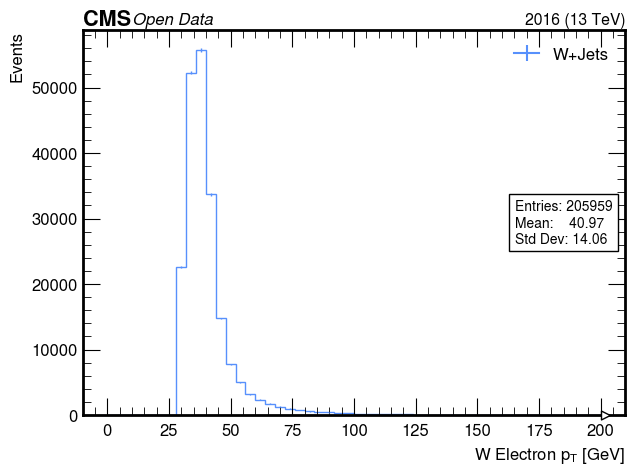

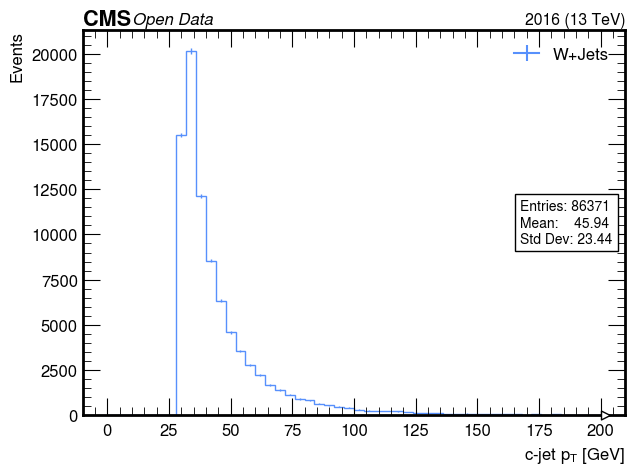

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='c-jet $p_{T}$ [GeV]', ylabel='Events'>,
 Hist(Regular(50, 0, 200, label='Axis 0'), storage=Double()) # Sum: 86125.0 (86371.0 with flow))

In [61]:
make_hist(
    W_Electron_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="W Electron $p_{T}$ [GeV]",
    ylabel="Events",
    label="W+Jets",
    logy=False,
    histtype='step',
    show_stats=True,
    ax=None,
    fname="Plots/W_Electron_Pt_selection.png",
    show=True,
    return_hist=True
)

make_hist(
    data=cJet_Pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="c-jet $p_{T}$ [GeV]",
    ylabel="Events",
    label="W+Jets",
    fname="Plots/c_Jet_Pt_min_deltaR_selection.png",
    logy=False,
    ax=None,
    show=True,
    return_hist=True,
    show_stats=True,
    histtype='step'
)